<div align="center">

<img src="../assets/logo.png" width="400">

# AUDITORÍA A LA CONTRATACIÓN PÚBLICA  
## Auditoria a la contratacion publica Plataforma SIA Observa – Vigencia 2025


**Entidad auditada:** 53 Sujetos de control 

**Tipo de análisis:** Auditoria basada en datos 

**Realizado por:** Wilmer Fidel Restrepo Orrego 
 
**Fecha de creacion:** 2026

**Fuente de los datos:** Plataforma Sia Observa 

</div>

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import seaborn as sns




sys.path.append(os.path.abspath(os.path.join('..')))
from src.cleaners import aplicar_tipos_datos, TIPOS_BASICO, TIPOS_EXTENDIDO, estandarizar_modalidades,estandarizar_causales,estandarizar_recursos_v2

from src import (
    setup_environment, RAW_DATA_PATH, BASE_DIR,
    aplicar_tipos_datos, TIPOS_BASICO, TIPOS_EXTENDIDO,
    formato_moneda_co, formato_miles_co,
    calcular_alertas_adicion
)


from src.environment import get_environment_info
from src.system import get_library_versions

setup_environment()
env = get_environment_info()
versions = get_library_versions()


print("""
AUDITORIA A LA CONTRATACION PUBLICA VIGENCIA 2025 -PLATAFORMA SIA OBSERVA
========================================================================
- Entorno configurado
- Los módulos de análisis y limpieza fueron vinculados
- Sistema listo para procesar datos de auditoria
""")



print (f"""
INFORME DEL ENTORNO DE DESARROLLO
=========================================================================
Sistema operativo : {env['os']}
Version Python    : {env['python']}
Kernel            : {env['kernel']}
Fecha ejecucion   : {env['timestamp']}
""")



print("""
VERSION DE LAS LIBRERIAS DEL PROYECTO
==========================================================================      
""")
for lib, version in versions.items():
    print (f"{lib.capitalize():<12}:{version}")


print (f"""
RUTAS DEL PROYECTO
===========================================================================
Base del proyecto:{BASE_DIR}
Datos crudos:{RAW_DATA_PATH}
""")


AUDITORIA A LA CONTRATACION PUBLICA VIGENCIA 2025 -PLATAFORMA SIA OBSERVA
- Entorno configurado
- Los módulos de análisis y limpieza fueron vinculados
- Sistema listo para procesar datos de auditoria


INFORME DEL ENTORNO DE DESARROLLO
Sistema operativo : Linux 6.17.0-20-generic
Version Python    : 3.12.3
Kernel            : CPython
Fecha ejecucion   : 2026-04-13 11:38:37


VERSION DE LAS LIBRERIAS DEL PROYECTO

Pandas      :3.0.0
Numpy       :2.4.2
Matplotlib  :3.10.8
Plotly      :6.5.2

RUTAS DEL PROYECTO
Base del proyecto:/home/wilo/Escritorio/auditoria_sia
Datos crudos:/home/wilo/Escritorio/auditoria_sia/data/raw



In [2]:
# BLOQUE DE CARGA, LIMPIEZA Y AUDITORÍA DE DATOS


print("Cargando archivos")
df_basico_raw = pd.read_excel(os.path.join(RAW_DATA_PATH, "Informe_Basico.xlsx"))
df_ext_raw = pd.read_excel(os.path.join(RAW_DATA_PATH, "Informe_Extendido.xlsx"))


print("Iniciando proceso de transformación y limpieza de los datos")
df_basico = aplicar_tipos_datos(df_basico_raw, TIPOS_BASICO)
df_ext = aplicar_tipos_datos(df_ext_raw, TIPOS_EXTENDIDO)

lista_dfs = []


for df in [df_basico, df_ext]:

    df["DURACION_REAL"] = (df["FECHA_TERMINACION"] - df["FECHA_ACTA_DE_INICIO"]).dt.days

    df["VIGENCIA"] = (
        pd.to_numeric(df["VIGENCIA"], errors="coerce").fillna(2025).astype("Int64")
    )

    df = estandarizar_modalidades(df)
    df = estandarizar_causales(df)
    df = estandarizar_recursos_v2(df)
    lista_dfs.append(df)

df_basico, df_ext = lista_dfs


print(f"""
PROCESAMIENTO COMPLETADO | {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
------------------------------------------------------------------------
INFORME BÁSICO   : {df_basico.shape[0]} filas y {df_basico.shape[1]} columnas procesadas.
INFORME EXTENDIDO: {df_ext.shape[0]} filas y {df_ext.shape[1]} columnas procesadas.
------------------------------------------------------------------------
""")


print("INSPECCIÓN DE INTEGRIDAD")
print("========================================================================")

pd.set_option("display.max_rows", None)


def realizar_qa_simple(df, nombre):
    print(f"\n{'='*40}")
    print(f"📊 REPORTE: {nombre}")
    print(f"{'='*40}")

    # Reporte de nulos resumido
    nulos = df.isna().sum()
    reporte = nulos[nulos > 0]

    if reporte.empty:
        print("✅ No hay nulos. ¡Todo melo!")
    else:
        print(reporte.sort_values(ascending=False))
    print(f"\nTotal filas: {len(df)}")


realizar_qa_simple(df_basico, "INFORME BÁSICO")
realizar_qa_simple(df_ext, "INFORME EXTENDIDO")


print("\n VISTA PREVIA DE LOS DATOS NORMALIZADOS - BASICO")
display(df_basico.head(5))

print("\n VISTA PREVIA DE LOS DATOS NORMALIZADOS - EXTENDIDO")
display(df_ext.head(5))

Cargando archivos
Iniciando proceso de transformación y limpieza de los datos

PROCESAMIENTO COMPLETADO | 2026-04-13 11:38:52
------------------------------------------------------------------------
INFORME BÁSICO   : 14199 filas y 25 columnas procesadas.
INFORME EXTENDIDO: 14138 filas y 33 columnas procesadas.
------------------------------------------------------------------------

INSPECCIÓN DE INTEGRIDAD

📊 REPORTE: INFORME BÁSICO
FECHA_TERMINACION_AMPLIADA    10252
NIT_1                             3
NOMBRE                            3
TIPO                              3
dtype: int64

Total filas: 14199

📊 REPORTE: INFORME EXTENDIDO
✅ No hay nulos. ¡Todo melo!

Total filas: 14138

 VISTA PREVIA DE LOS DATOS NORMALIZADOS - BASICO


,TIPO_DE_ENTIDAD,NIT,ENTIDAD,VIGENCIA,CODIGO_CONTRATO,VALOR_INICIAL_CONTRATO,ADICIONES,LIBERACIONES,VALOR_VIGENTE,FECHA_SUSCRIPCION,FECHA_ACTA_DE_INICIO,FECHA_TERMINACION,TIEMPO_EJECUCION,MODALIDAD_CONTRATACION,CAUSAL_CONTRATO,TIPO_CONTRATO,FECHA_CREACION,FECHA_TERMINACION_AMPLIADA,NIT_1,NOMBRE,TIPO,ESTADO_CONTRATO,DURACION_REAL,MODALIDAD_ESTANDAR,CAUSAL_ESTANDAR
0,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-01-2025,"17,676,000.00",0.00,0.00,"17,676,000.00",2025-01-01,2025-01-01,2025-12-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,24547202,MARIA LILIANA MONTES HOYOS,Contratista,RENDIDO,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO
1,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-02-2025,"8,846,800.00",0.00,0.00,"8,846,800.00",2025-01-01,2025-01-01,2025-12-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,900010878,GRUPO METRO Y CIA. LTDA,Contratista,RENDIDO,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO
2,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-03-2025,"22,176,000.00",0.00,0.00,"22,176,000.00",2025-01-02,2025-01-02,2025-12-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,1088290219,DIANA MARCELA RIOS AGUIRRE,Contratista,RENDIDO,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO
3,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-04-2025,"7,584,000.00",0.00,0.00,"7,584,000.00",2025-01-02,2025-01-02,2025-12-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,1089719111,LINA MARCELA GONZALEZ GUTIERREZ,Contratista,RENDIDO,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO
4,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-05-2025,"26,400,000.00",0.00,0.00,"26,400,000.00",2025-01-02,2025-01-02,2025-12-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,2025-01-31,NaT,1088319762,MARIA FERNANDA ACOSTA REMIREZ,Contratista,RENDIDO,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO



 VISTA PREVIA DE LOS DATOS NORMALIZADOS - EXTENDIDO


,TIPO_DE_ENTIDAD,NIT,ENTIDAD,VIGENCIA,CODIGO_CONTRATO,OBJETO_CONTRATO,FECHA_SUSCRIPCION,FECHA_ACTA_DE_INICIO,FECHA_TERMINACION,TIEMPO_EJECUCION,VALOR_INICIAL_CONTRATO,ADICIONES,LIBERACIONES,VALOR_VIGENTE,MODALIDAD_CONTRATACION,CAUSAL_CONTRATO,TIPO_CONTRATO,NIT_1,NOMBRE,TIPO,NIT_2,NOMBRE_1,TIPO_1,NOMBRE_DEL_RUBRO,APROPIACION_INICIAL,ORIGEN_RECURSOS,CDPS,RPS,FECHA_CREACION,DURACION_REAL,MODALIDAD_ESTANDAR,CAUSAL_ESTANDAR,ORIGEN_RECURSOS_ESTANDAR
0,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-01-2025,ARRENDAMIENTO DE INMUEBLE CON DESTINACION COME...,2025-01-01,2025-01-01,2025-12-31,364,"17,676,000.00",0.00,0.00,"17,676,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,24547202,MARIA LILIANA MONTES HOYOS,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS FINANCIEROS Y SERVICIOS CONEXOS; SER...,"68,266,800.00",RECURSOS PROPIOS,20250001,20250001,2025-01-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS
1,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-02-2025,"CONTRATAR LA IMPLEMENTACION, PUESTA EN FUNCION...",2025-01-01,2025-01-01,2025-12-31,364,"8,846,800.00",0.00,0.00,"8,846,800.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,900010878,GRUPO METRO Y CIA. LTDA,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,PAQUETES DE SOFTWARE,"9,072,000.00",RECURSOS PROPIOS,20250003,20250003,2025-01-31,364,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS
2,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-03-2025,PRESTAR EL SERVICIO PROFESIONAL EN EL CARGO DE...,2025-01-02,2025-01-02,2025-12-31,363,"22,176,000.00",0.00,0.00,"22,176,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,1088290219,DIANA MARCELA RIOS AGUIRRE,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS PRESTADOS A LAS EMPRESAS Y SERVICIOS...,"171,903,986.00",RECURSOS PROPIOS,20250005,20250003,2025-01-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS
3,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-04-2025,PRESTAR LOS SERVICIOS PROFESIONALES COMO PERSO...,2025-01-02,2025-01-02,2025-12-31,363,"7,584,000.00",0.00,0.00,"7,584,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,1089719111,LINA MARCELA GONZALEZ GUTIERREZ,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS PRESTADOS A LAS EMPRESAS Y SERVICIOS...,"171,903,986.00",RECURSOS PROPIOS,20250007,20250007,2025-01-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS
4,SOCIEDADES DE ECONOMIA MIXTA,901685734,UMBRALED S.A.S E.S.P.,2025,UMB-05-2025,PRESTAR EL SERVICIO PROFESIONAL DE ASESORIA JU...,2025-01-02,2025-01-02,2025-12-31,363,"26,400,000.00",0.00,0.00,"26,400,000.00",CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,APOYO A LA GESTION,1088319762,MARIA FERNANDA ACOSTA REMIREZ,Contratista,1088332330,JORGE WILLIAM GONZALEZ TAMAYO,Interno,SERVICIOS PRESTADOS A LAS EMPRESAS Y SERVICIOS...,"171,903,986.00",RECURSOS PROPIOS,20250009,20250009,2025-01-31,363,CONTRATACION DIRECTA,PRESTACION DE SERVICIOS PROFESIONALES Y APOYO,RECURSOS PROPIOS


In [3]:
realizar_qa_simple(df_basico, "BÁSICO")


📊 REPORTE: BÁSICO
FECHA_TERMINACION_AMPLIADA    10252
NIT_1                             3
NOMBRE                            3
TIPO                              3
dtype: int64

Total filas: 14199


In [4]:
realizar_qa_simple(df_basico, "BÁSICO")


📊 REPORTE: BÁSICO
FECHA_TERMINACION_AMPLIADA    10252
NIT_1                             3
NOMBRE                            3
TIPO                              3
dtype: int64

Total filas: 14199


In [5]:
# ============================================================================
# BLOQUE DE EXPORTACIÓN DE DATOS PROCESADOS (AJUSTADO PARA EXCEL LIMPIO)
# ============================================================================
import os

# 1. DEFINIR LA RUTA
PROCESSED_DATA_PATH = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print("💾 Iniciando exportación de archivos procesados...")

try:
    # --- PASO PREVIO: LIMPIEZA VISUAL PARA EL CSV ---
    # Creamos copias para no dañar los cálculos de fechas en el Notebook
    df_basico_export = df_basico.copy()
    df_ext_export = df_ext.copy()

    for df_temp in [df_basico_export, df_ext_export]:
        # Buscamos todas las columnas que sean de tipo fecha
        cols_fecha = df_temp.select_dtypes(include=["datetime64"]).columns
        for col in cols_fecha:
            # Las convertimos a texto simple YYYY-MM-DD (adiós a las horas 00:00:00)
            df_temp[col] = df_temp[col].dt.strftime("%Y-%m-%d")

        # Opcional: Si tienes columnas con números muy grandes que salen con .0
        # puedes descomentar la siguiente línea para que salgan como enteros:
        # df_temp['VALOR_CONTRATO'] = df_temp['VALOR_CONTRATO'].fillna(0).astype(int)

    # 3. Exportar Informe Básico (Usamos la versión limpia)
    ruta_basico = os.path.join(PROCESSED_DATA_PATH, "Informe_Basico_Procesado.csv")
    df_basico_export.to_csv(ruta_basico, index=False, encoding="utf-8-sig", sep=";")

    # 4. Exportar Informe Extendido (Usamos la versión limpia)
    ruta_ext = os.path.join(PROCESSED_DATA_PATH, "Informe_Extendido_Procesado.csv")
    df_ext_export.to_csv(ruta_ext, index=False, encoding="utf-8-sig", sep=";")

    print(f"""
✅ ¡PROCESO EXITOSO!
------------------------------------------------------------------------
Los archivos se guardaron correctamente en la ruta raíz:
📍 {os.path.abspath(PROCESSED_DATA_PATH)}

⚙️ Ajustes realizados para Excel:
- Fechas normalizadas a YYYY-MM-DD (sin horas).
- Codificación UTF-8-SIG para tildes y eñes.
- Separador ';' para apertura directa en Excel.
------------------------------------------------------------------------
""")

except Exception as e:
    print(f"❌ Error al exportar: {e}")

💾 Iniciando exportación de archivos procesados...

✅ ¡PROCESO EXITOSO!
------------------------------------------------------------------------
Los archivos se guardaron correctamente en la ruta raíz:
📍 /home/wilo/Escritorio/auditoria_sia/data/processed

⚙️ Ajustes realizados para Excel:
- Fechas normalizadas a YYYY-MM-DD (sin horas).
- Codificación UTF-8-SIG para tildes y eñes.
- Separador ';' para apertura directa en Excel.
------------------------------------------------------------------------



In [6]:
from src.analysis import calcular_resumen_contratos  # Asumiendo que esa es tu ruta

# Invocas la función
resumen = calcular_resumen_contratos(df_ext)

print(f"📊 --- RESULTADOS DE AUDITORÍA ---")
print(f"✅ Total Contratos: {resumen['cantidad']}")
print(f"💰 Valor Total: ${resumen['total_suma']:,.2f}")
print(f"📉 Valor Promedio: ${resumen['promedio']:,.2f}")
print("-" * 40)
print(f"🏆 CONTRATO TOP (Mayor Valor):")
print(f"🏢 Entidad: {resumen['mayor_contrato']['entidad']}")
print(f"🆔 Código: {resumen['mayor_contrato']['codigo']}")
print(f"💵 Valor: ${resumen['mayor_contrato']['valor']:,.2f}")
print(f"💵 objeto: {resumen['mayor_contrato']['objeto']}")

📊 --- RESULTADOS DE AUDITORÍA ---
✅ Total Contratos: 14138
💰 Valor Total: $1,329,649,976,891.29
📉 Valor Promedio: $94,047,954.23
----------------------------------------
🏆 CONTRATO TOP (Mayor Valor):
🏢 Entidad: EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA
🆔 Código: 307-2025
💵 Valor: $98,405,360,859.00
💵 objeto: CONSTRUCCION DE LA ESTRUCTURA DEL EDIFICO DE ALTA COMPLEJIDAD DEL PROYECTO HOSPITAL REGIONAL DE ALTA COMPLEJIDAD EN EL DEPARTAMENTO DE RISARALDA


In [7]:
from src.analysis import contratacion_por_tipo_entidad

# Ejecutamos el análisis por grupo
df_por_entidad = contratacion_por_tipo_entidad(df_ext)

print("🏢 ANÁLISIS POR TIPO DE ENTIDAD")
display(df_por_entidad)

# Si quieres ver solo la entidad con más plata:
entidad_top = df_por_entidad.iloc[0]["TIPO_DE_ENTIDAD"]
print(f"\n📢 La mayor inversión está en: {entidad_top}")

🏢 ANÁLISIS POR TIPO DE ENTIDAD


,TIPO_DE_ENTIDAD,CANTIDAD_CONTRATOS,VALOR_TOTAL
5,ENTIDADES TERRITORIALES,7609,"661,975,700,550.35"
4,EMPRESAS SOCIALES DEL ESTADO,4464,"382,860,344,191.53"
3,EMPRESAS INDUSTRIALES Y COMERCIALES DEL ESTADO,569,"181,785,600,313.00"
2,EMPRESA DE SERVICIOS PUBLICOS,942,"84,637,736,788.55"
0,AREAS METROPOLITANAS,361,"14,254,334,544.86"
6,ESTABLECIMIENTO PUBLICOS,123,"2,739,627,498.00"
1,ASOCIACION ENTRE ENTIDADES PUBLICAS,49,"984,830,573.00"
7,SOCIEDADES DE ECONOMIA MIXTA,21,"411,802,432.00"



📢 La mayor inversión está en: ENTIDADES TERRITORIALES


/tmp/ipykernel_22462/864106098.py:46: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/wilo/Escritorio/auditoria_sia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


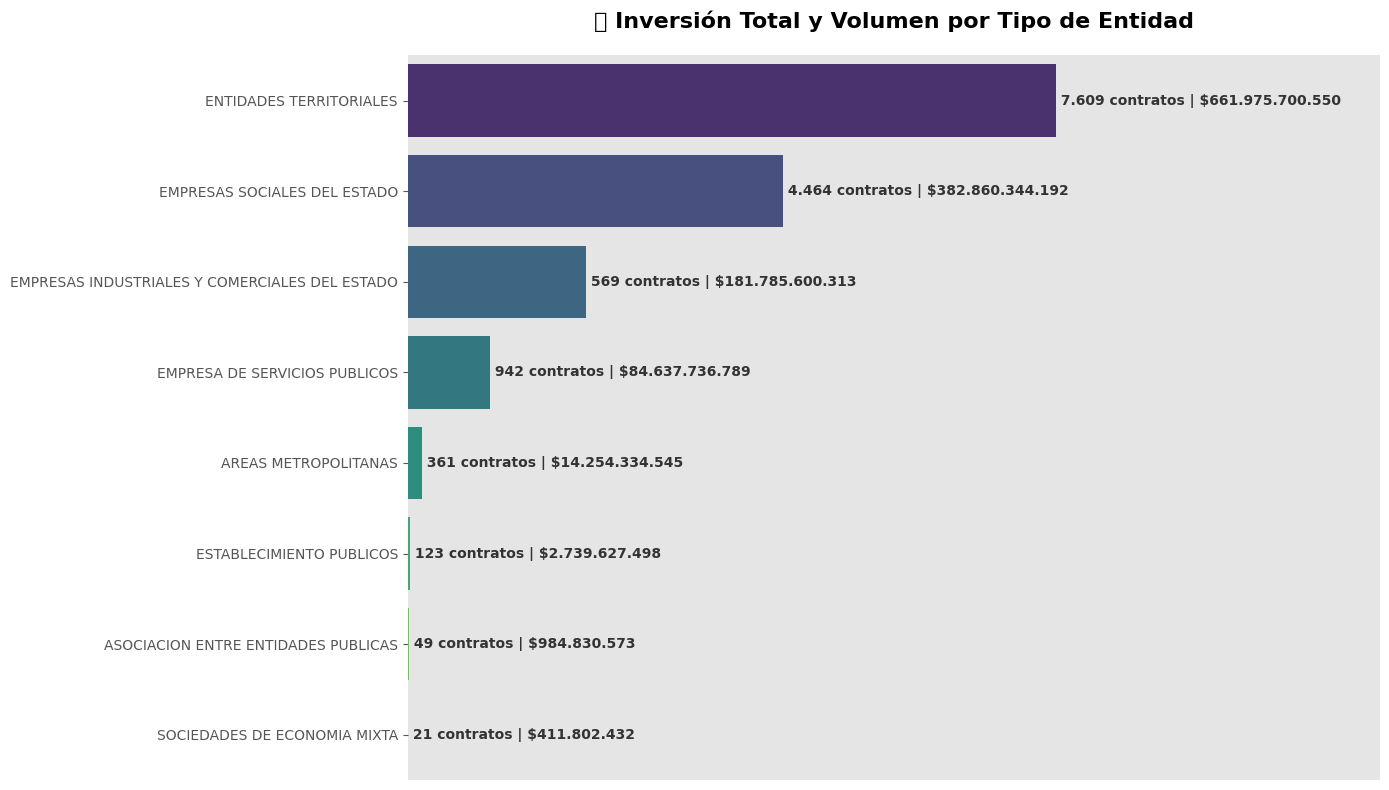

In [8]:
# 1. Obtener los datos agrupados
df_grafica = contratacion_por_tipo_entidad(df_ext)

# 2. Configuración de la figura
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_grafica, 
    x="VALOR_TOTAL", 
    y="TIPO_DE_ENTIDAD", 
    palette="viridis",
    hue="TIPO_DE_ENTIDAD",
    legend=False
)

# 3. EL TRUCO: Agregar etiquetas personalizadas a cada barra
for i, bar in enumerate(ax.patches):
    # Obtenemos los valores de esa fila
    monto = df_grafica.iloc[i]["VALOR_TOTAL"]
    cantidad = df_grafica.iloc[i]["CANTIDAD_CONTRATOS"]
    
    # Creamos el texto formateado
    # Ejemplo: 222 contratos | $2.222.222.222
    label_text = f" {int(cantidad):,} contratos | ${monto:,.0f}".replace(",", ".")
    
    # Posicionamos el texto al final de la barra
    ax.text(
        bar.get_width(),       # Posición X (final de la barra)
        bar.get_y() + bar.get_height()/2, # Posición Y (centro de la barra)
        label_text, 
        va='center',           # Alineación vertical
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# 4. Limpieza estética
plt.title("💰 Inversión Total y Volumen por Tipo de Entidad", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("") # Quitamos el título del eje X
plt.ylabel("") # Quitamos el título del eje Y para que no estorbe
plt.xticks([]) # QUITAMOS LOS NÚMEROS AMONTONADOS DEL EJE X

# 5. Ajustar márgenes para que el texto largo quepa
plt.xlim(0, df_grafica["VALOR_TOTAL"].max() * 1.5) # Damos un 50% más de espacio a la derecha
sns.despine(left=True, bottom=True) # Quitamos los bordes de la gráfica para que se vea moderna

plt.tight_layout()
plt.show()

In [9]:
from src.analysis import analizar_por_tipo_contrato

# Obtener datos
df_tipo_contrato = analizar_por_tipo_contrato(df_ext)

print("📋 TABLA RESUMEN: PARTICIPACIÓN POR TIPO DE CONTRATO")
# Formateamos la tabla para que se vea bonita al mostrarla
df_estilo = df_tipo_contrato.copy()
df_estilo['VALOR_TOTAL'] = df_estilo['VALOR_TOTAL'].map('${:,.0f}'.format).str.replace(',', '.')
df_estilo['PORCENTAJE_PARTICIPACION'] = df_estilo['PORCENTAJE_PARTICIPACION'].map('{:.2f}%'.format)
display(df_estilo)

📋 TABLA RESUMEN: PARTICIPACIÓN POR TIPO DE CONTRATO


,TIPO_CONTRATO,CANTIDAD,VALOR_TOTAL,PORCENTAJE_PARTICIPACION
5,CONTRATO DE PRESTACION DE SERVICIOS,9196,$565.993.004.467,65.04%
0,APOYO A LA GESTION,2406,$63.520.253.016,17.02%
9,SUMINISTRO,1716,$225.696.627.015,12.14%
6,CONVENIOS,293,$123.619.518.540,2.07%
1,COMPRAVENTA,215,$38.694.321.259,1.52%
4,CONTRATO DE OBRA,205,$286.857.201.812,1.45%
2,CONTRATO DE CONSULTORIA,51,$7.974.367.759,0.36%
3,CONTRATO DE INTERVENTORIA,50,$17.095.124.210,0.35%
7,DERIVADOS DE LA AUTONOMIA DE LA VOLUNTAD,5,$110.915.480,0.04%
8,ENCARGOS FIDUCIARIOS,1,$88.643.334,0.01%


/tmp/ipykernel_22462/3994518003.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/home/wilo/Escritorio/auditoria_sia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


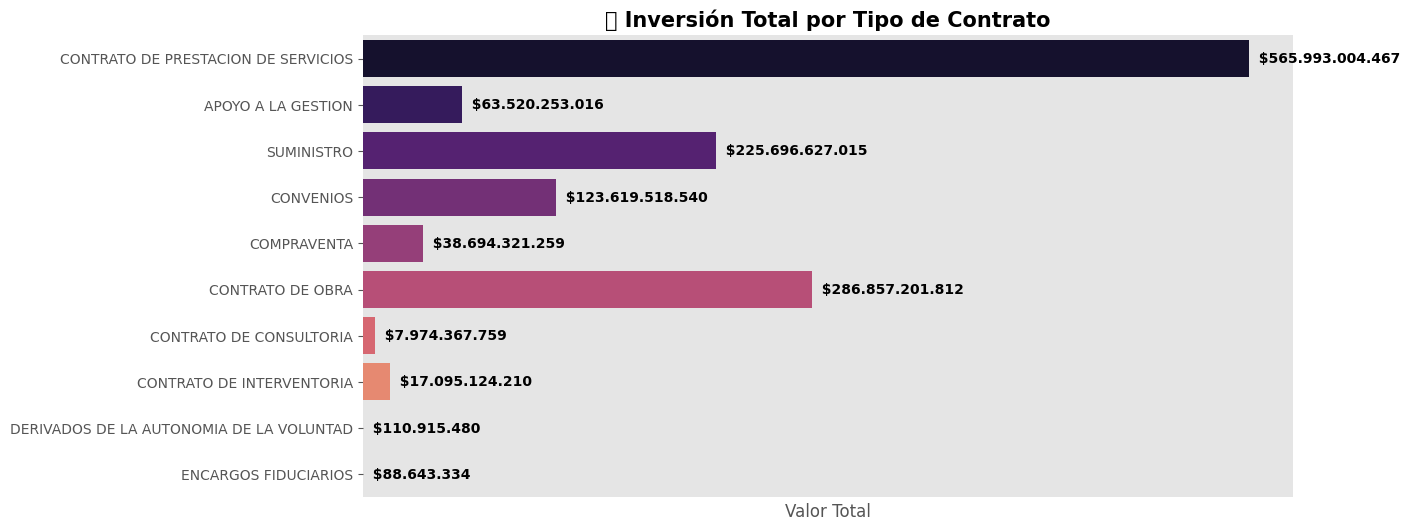

In [10]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_tipo_contrato, 
    x="VALOR_TOTAL", 
    y="TIPO_CONTRATO", 
    palette="magma"
)

# Anotamos el dinero en cada barra
for i, bar in enumerate(ax.patches):
    monto = df_tipo_contrato.iloc[i]["VALOR_TOTAL"]
    ax.text(
        bar.get_width(), 
        bar.get_y() + bar.get_height()/2, 
        f"  ${monto:,.0f}".replace(",", "."), 
        va='center', fontweight='bold'
    )

plt.title("💰 Inversión Total por Tipo de Contrato", fontsize=15, fontweight='bold')
plt.xlabel("Valor Total")
plt.ylabel("")
plt.xticks([]) # Quitamos los números del eje X
sns.despine(left=True, bottom=True)
plt.show()

/tmp/ipykernel_22462/3752421223.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/wilo/Escritorio/auditoria_sia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


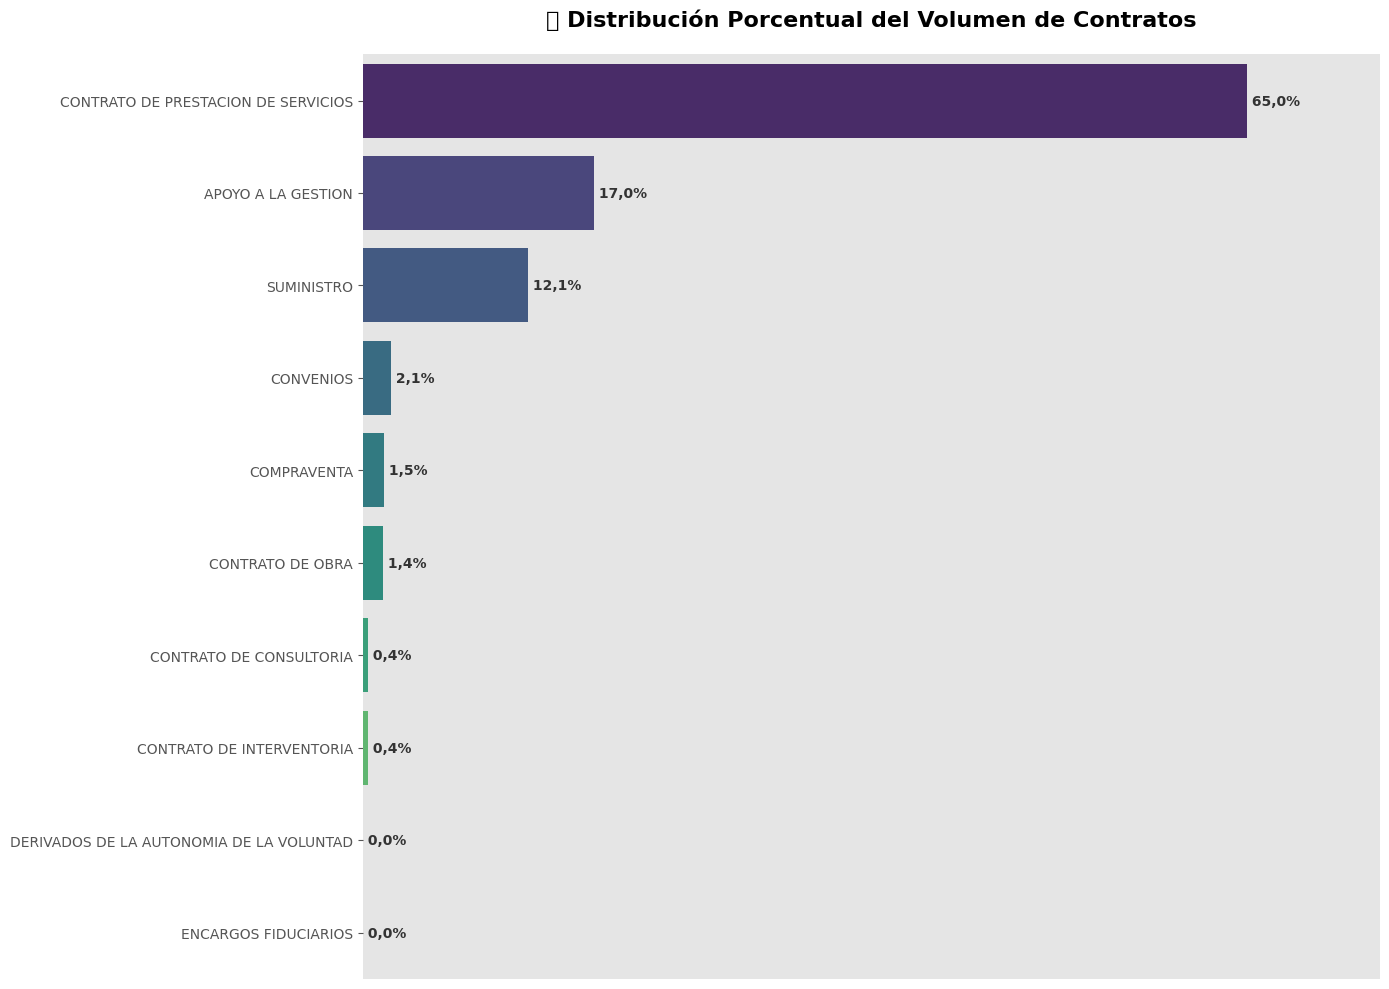

In [11]:
# 1. Obtenemos los datos agrupados usando la función que ya definimos
df_tipo_contrato = analizar_por_tipo_contrato(df_ext)

# 2. Configuración de la figura para que sea legible
plt.figure(figsize=(14, 10)) # Más alta para dar espacio a todas las categorías

# Usamos barras horizontales para que los nombres largos se lean de una
ax = sns.barplot(
    data=df_tipo_contrato, 
    x="PORCENTAJE_PARTICIPACION", # Porcentaje en el eje X
    y="TIPO_CONTRATO",           # Categorías en el eje Y
    palette="viridis",           # Degradado profesional
    hue="TIPO_CONTRATO",
    legend=False
)

# 3. EL TRUCO DE AUDITOR: Anotar el porcentaje exacto al final de cada barra
for bar in ax.patches:
    # Obtenemos el valor porcentual de esa barra
    porcentaje = bar.get_width()
    
    # Creamos la etiqueta con el formato X.X%
    label_text = f" {porcentaje:.1f}%".replace(".", ",") # Usamos coma para decimales
    
    # Posicionamos el texto
    ax.text(
        bar.get_width(),       # Posición X (final de la barra)
        bar.get_y() + bar.get_height()/2, # Posición Y (centro)
        label_text, 
        va='center',           # Alineación vertical
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# 4. Ajustes estéticos y de Limpieza
plt.title("📊 Distribución Porcentual del Volumen de Contratos", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("") # Quitamos el título del eje X
plt.ylabel("") # Quitamos el título del eje Y
plt.xticks([]) # QUITAMOS LOS NÚMEROS AMONTONADOS DEL EJE X

# 5. Dar aire y limpiar bordes
plt.xlim(0, df_tipo_contrato["PORCENTAJE_PARTICIPACION"].max() * 1.15) # 15% más de espacio a la derecha
sns.despine(left=True, bottom=True) # Quitamos los bordes de la gráfica

plt.tight_layout()
plt.show()

/tmp/ipykernel_22462/3037535458.py:40: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/wilo/Escritorio/auditoria_sia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127963 (\N{CLASSICAL BUILDING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


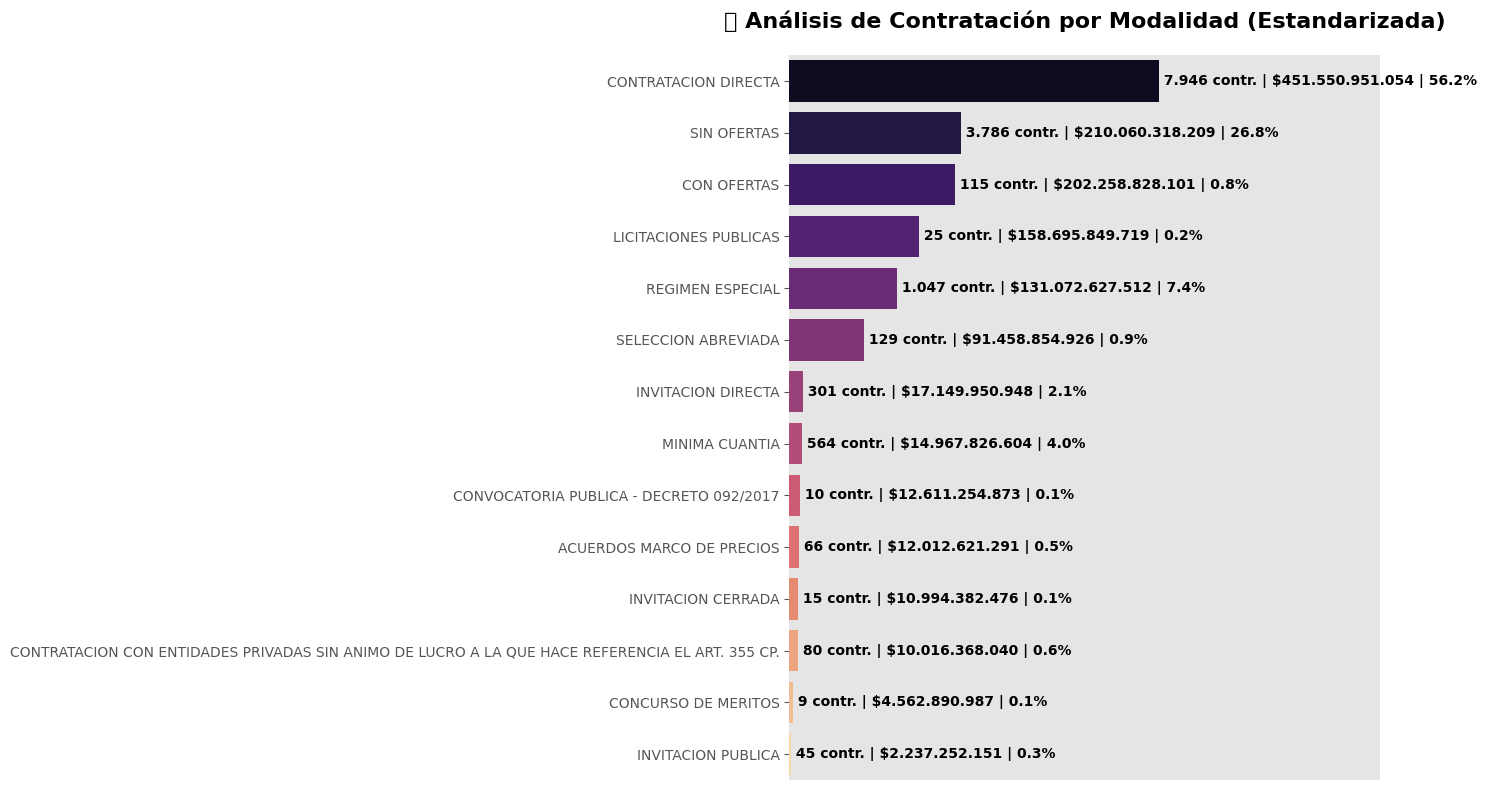


📋 TABLA RESUMEN DE MODALIDADES


,MODALIDAD_ESTANDAR,CANTIDAD,VALOR_TOTAL,%_PARTICIPACION
4,CONTRATACION DIRECTA,7946,$ 451.550.951.054,56.20%
13,SIN OFERTAS,3786,$ 210.060.318.209,26.78%
1,CON OFERTAS,115,$ 202.258.828.101,0.81%
9,LICITACIONES PUBLICAS,25,$ 158.695.849.719,0.18%
11,REGIMEN ESPECIAL,1047,$ 131.072.627.512,7.41%
12,SELECCION ABREVIADA,129,$ 91.458.854.926,0.91%
7,INVITACION DIRECTA,301,$ 17.149.950.948,2.13%
10,MINIMA CUANTIA,564,$ 14.967.826.604,3.99%
5,CONVOCATORIA PUBLICA - DECRETO 092/2017,10,$ 12.611.254.873,0.07%
0,ACUERDOS MARCO DE PRECIOS,66,$ 12.012.621.291,0.47%


In [12]:
from src.analysis import analizar_por_modalidad

# 1. Obtener los datos
df_modalidad = analizar_por_modalidad(df_ext)

# 2. Configuración de la gráfica
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_modalidad, 
    x="VALOR_TOTAL", 
    y="MODALIDAD_ESTANDAR", 
    palette="magma",
    hue="MODALIDAD_ESTANDAR",
    legend=False
)

# 3. Anotaciones de Auditoría (Cantidad | Valor | %)
for i, bar in enumerate(ax.patches):
    monto = df_modalidad.iloc[i]["VALOR_TOTAL"]
    cant = df_modalidad.iloc[i]["CANTIDAD"]
    porc = df_modalidad.iloc[i]["%_PARTICIPACION"]
    
    # Texto formateado para Colombia (Puntos para miles)
    label = f" {int(cant):,} contr. | ${monto:,.0f} | {porc:.1f}%".replace(",", ".")
    
    ax.text(
        bar.get_width(), 
        bar.get_y() + bar.get_height()/2, 
        label, 
        va='center', fontweight='bold', fontsize=10
    )

# 4. Estética final de la gráfica
plt.title("🏛️ Análisis de Contratación por Modalidad (Estandarizada)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("")
plt.ylabel("")
plt.xticks([]) 
plt.xlim(0, df_modalidad["VALOR_TOTAL"].max() * 1.6) 
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 5. TABLA RESUMEN CON ESTILO (Mejorada)
print("\n" + "="*50)
print("📋 TABLA RESUMEN DE MODALIDADES")
print("="*50)

# Aplicamos estilos: Fondo de color para resaltar montos y barras de progreso visuales
tabla_estilizada = df_modalidad.style.format({
    'VALOR_TOTAL': lambda x: f"$ {x:,.0f}".replace(",", "."),
    '%_PARTICIPACION': "{:.2f}%"
}).bar(subset=['VALOR_TOTAL'], color='') \
  .set_properties(**{'text-align': 'left', 'font-family': 'Arial'}) \
  .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])

display(tabla_estilizada)

/tmp/ipykernel_22462/2294839802.py:40: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/wilo/Escritorio/auditoria_sia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


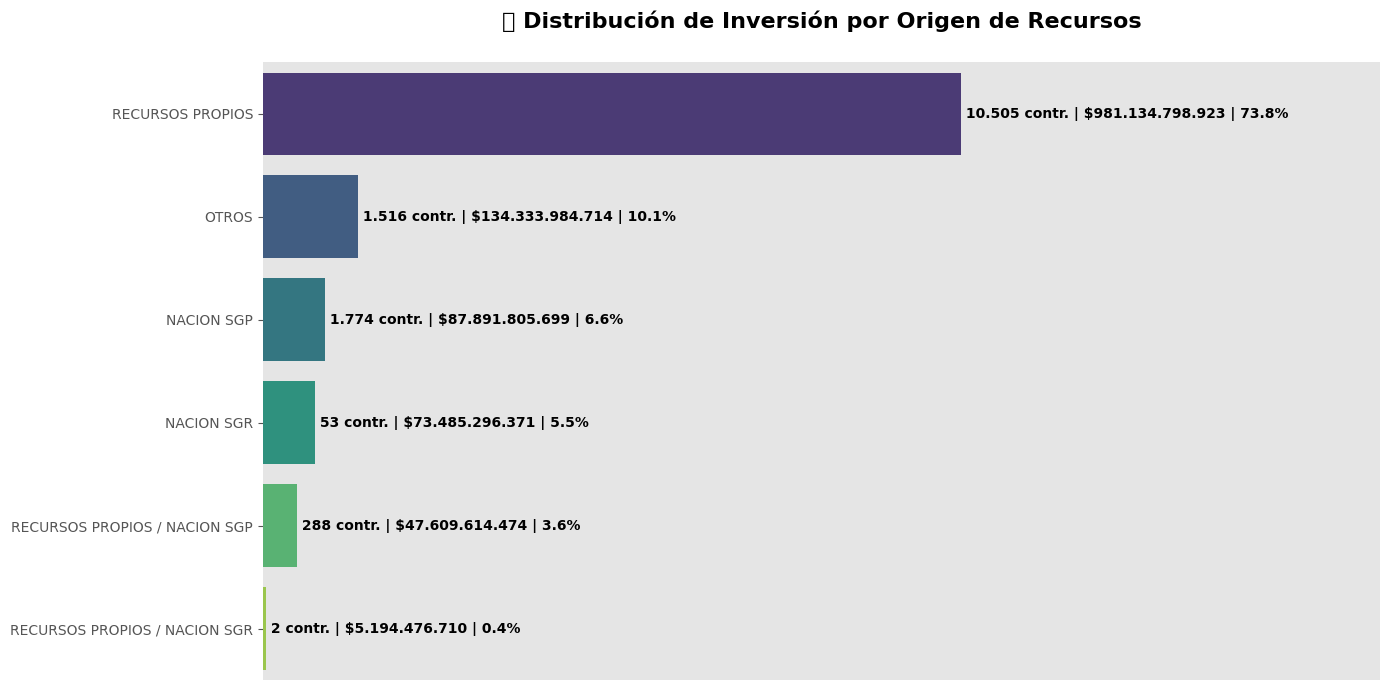


📋 RESUMEN FINANCIERO POR FUENTE DE FINANCIACIÓN:


,ORIGEN_RECURSOS_ESTANDAR,CANTIDAD_CONTRATOS,VALOR_TOTAL,%_INVERSION
3,RECURSOS PROPIOS,10505,$ 981.134.798.923,73.79%
2,OTROS,1516,$ 134.333.984.714,10.10%
0,NACION SGP,1774,$ 87.891.805.699,6.61%
1,NACION SGR,53,$ 73.485.296.371,5.53%
4,RECURSOS PROPIOS / NACION SGP,288,$ 47.609.614.474,3.58%
5,RECURSOS PROPIOS / NACION SGR,2,$ 5.194.476.710,0.39%


In [13]:
from src.analysis import analizar_por_origen_recursos

# 1. Obtener los datos calculados
df_recursos = analizar_por_origen_recursos(df_ext)

# 2. Configuración de la gráfica
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_recursos, 
    x="VALOR_TOTAL", 
    y="ORIGEN_RECURSOS_ESTANDAR", 
    palette="viridis",
    hue="ORIGEN_RECURSOS_ESTANDAR",
    legend=False
)

# 3. Anotaciones detalladas (Cantidad | Valor | % Inversión)
for i, bar in enumerate(ax.patches):
    monto = df_recursos.iloc[i]["VALOR_TOTAL"]
    cant = df_recursos.iloc[i]["CANTIDAD_CONTRATOS"]
    porc = df_recursos.iloc[i]["%_INVERSION"]
    
    # Formato: 120 contr. | $5.000.000 | 25.4%
    label = f" {int(cant):,} contr. | ${monto:,.0f} | {porc:.1f}%".replace(",", ".")
    
    ax.text(
        bar.get_width(), 
        bar.get_y() + bar.get_height()/2, 
        label, 
        va='center', fontweight='bold', fontsize=10
    )

# 4. Estética de la gráfica
plt.title("💰 Distribución de Inversión por Origen de Recursos", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("")
plt.ylabel("")
plt.xticks([]) # Limpiamos el eje X
plt.xlim(0, df_recursos["VALOR_TOTAL"].max() * 1.6) # Espacio para el texto
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 5. TABLA RESUMEN ESTILIZADA
print("\n📋 RESUMEN FINANCIERO POR FUENTE DE FINANCIACIÓN:")
tabla_fuentes = df_recursos.style.format({
    'VALOR_TOTAL': lambda x: f"$ {x:,.0f}".replace(",", "."),
    '%_INVERSION': "{:.2f}%"
}).background_gradient(subset=['%_INVERSION'], cmap='Greens') \
  .set_properties(**{'text-align': 'left'})

display(tabla_fuentes)

In [20]:
from src.analysis import analizar_ranking_entidades

# 1. Obtener los datos del ranking
df_ranking = analizar_ranking_entidades(df_ext)

# 2. Presentación de la Tabla Resumen Estilizada
print("🏆 RANKING DE ENTIDADES POR MONTO CONTRATADO")
print("-" * 50)

# Aplicamos un estilo profesional
ranking_estilizado = df_ranking.head(20).style.format({
    'VALOR_TOTAL': lambda x: f"$ {x:,.0f}".replace(",", "."),
    'CANTIDAD_CONTRATOS': "{:,}"
}).background_gradient(subset=['VALOR_TOTAL'], cmap='YlOrRd') \
  .set_properties(**{'text-align': 'left'}) \
  .set_table_styles([
      {'selector': 'th', 'props': [('background-color', '#1a5276'), ('color', 'white'), ('font-weight', 'bold')]}
  ])

# Mostramos el Top 20 (puedes quitar el .head(20) si quieres ver todas)
display(ranking_estilizado)

🏆 RANKING DE ENTIDADES POR MONTO CONTRATADO
--------------------------------------------------


,ENTIDAD,CANTIDAD_CONTRATOS,VALOR_TOTAL
32,GOBERNACION DE RISARALDA,"3,793",$ 476.002.998.528
29,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,396,$ 171.631.847.052
36,HOSPITAL SAN JORGE DE PEREIRA,"1,089",$ 169.863.209.720
47,HOSPITAL SANTA MONICA,551,$ 76.835.144.340
10,ALCALDIA DE SANTA ROSA DE CABAL,"1,017",$ 43.507.767.550
40,HOSPITAL SAN PEDRO Y SAN PABLO LA VIRGINIA,333,$ 29.756.312.199
8,ALCALDIA DE PUEBLO RICO,459,$ 29.127.970.893
44,HOSPITAL SAN VICENTE DE PAUL DE SANTA ROSA DE CABAL,386,$ 22.686.370.229
7,ALCALDIA DE MISTRATO,411,$ 18.021.949.123
26,EMPRESA DE SERVICIOS PUBLICOS DE SANTA ROSA DE CABAL,106,$ 16.375.009.032


In [16]:
from src.analysis import calcular_alertas_adicion

# 1. Ejecutar el cálculo sobre el informe extendido
df_con_alertas = calcular_alertas_adicion(df_ext)

# 2. Capturar los que superan el 50% (Zona Roja)
# Importante: El texto debe coincidir con el de la función ("ALERTA_ROJA")
sospechosos = df_con_alertas[df_con_alertas["ESTADO_ADICION"] == "ALERTA_ROJA"].copy()

# 3. Reporte de Auditoría
print(f"🚨 ALERTA DE AUDITORÍA: Se detectaron {len(sospechosos)} contratos con adiciones críticas.")

if not sospechosos.empty:
    print("\n📋 TABLA RESUMEN: CONTRATOS QUE SUPERAN EL 50% DE ADICIÓN")
    
    # Seleccionamos solo las columnas que pidió, senior
    reporte_final = sospechosos[['ENTIDAD', 'CODIGO_CONTRATO', 'PORCENTAJE_ADICION']].sort_values(by="PORCENTAJE_ADICION", ascending=False)
    
    # Le damos formato profesional
    display(reporte_final.style.format({
        'PORCENTAJE_ADICION': '{:.2f}%'
    }).background_gradient(subset=['PORCENTAJE_ADICION'], cmap='Reds'))
else:
    # Si sigue saliendo 0, miremos los que tienen cualquier adición para ver si el dato existe
    print("✅ No hay contratos > 50%.")
    con_algo = df_con_alertas[df_con_alertas["PORCENTAJE_ADICION"] > 0]
    print(f"ℹ️ Nota: Se encontraron {len(con_algo)} contratos con adiciones menores al 50%.")

🚨 ALERTA DE AUDITORÍA: Se detectaron 0 contratos con adiciones críticas.
✅ No hay contratos > 50%.
ℹ️ Nota: Se encontraron 2916 contratos con adiciones menores al 50%.


In [18]:
from src.analysis import analizar_rendicion_extemporanea, resumen_extemporaneos_por_entidad

# 1. Ejecutar el cálculo sobre el INFORME BÁSICO
df_resultado = analizar_rendicion_extemporanea(df_basico)

print(f"📊 TOTAL DE CONTRATOS RENDIDOS EXTEMPORÁNEOS: {len(df_resultado)}")

# --- TABLA 1: DETALLE DE CONTRATOS ---
print("\n📋 DETALLE DE EXTEMPORANEIDAD (TOP 10 MÁS CRÍTICOS):")
columnas_detalle = ['ENTIDAD', 'CODIGO_CONTRATO', 'FECHA_ACTA_DE_INICIO', 'FECHA_CREACION', 'DIAS_EXTEMPORANEIDAD']

display(df_resultado[columnas_detalle]
        .sort_values(by="DIAS_EXTEMPORANEIDAD", ascending=False)
        .head(10)
        .style.background_gradient(subset=['DIAS_EXTEMPORANEIDAD'], cmap='YlOrRd'))

# --- TABLA 2: RESUMEN POR ENTIDAD ---
print("\n🏢 RESUMEN DE INCUMPLIMIENTO POR ENTIDAD:")
df_resumen_entidad = resumen_extemporaneos_por_entidad(df_resultado)

display(df_resumen_entidad.style.format({
    'PROMEDIO_DIAS_RETRASO': '{:.1f} días'
}).bar(subset=['TOTAL_CONTRATOS_EXTEMPORANEOS'], color='#d9534f'))

📊 TOTAL DE CONTRATOS RENDIDOS EXTEMPORÁNEOS: 728

📋 DETALLE DE EXTEMPORANEIDAD (TOP 10 MÁS CRÍTICOS):


,ENTIDAD,CODIGO_CONTRATO,FECHA_ACTA_DE_INICIO,FECHA_CREACION,DIAS_EXTEMPORANEIDAD
9028,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,205-2025,2025-07-25 00:00:00,2026-01-05 00:00:00,164
9027,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,204-2025,2025-07-25 00:00:00,2026-01-05 00:00:00,164
9026,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,201-2025,2025-07-28 00:00:00,2026-01-05 00:00:00,161
9029,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,212-2025,2025-07-29 00:00:00,2026-01-05 00:00:00,160
9030,EMPRESA TERRITORIAL DE DESARROLLO URBANO Y RURAL DE RISARALDA,215-2025,2025-07-30 00:00:00,2026-01-05 00:00:00,159
9359,EMPRESA DE SERVICIOS PUBLICOS DE SANTA ROSA DE CABAL,CI001-2025,2025-02-14 00:00:00,2025-07-14 00:00:00,150
7384,GOBERNACION DE RISARALDA,1848,2025-04-29 00:00:00,2025-09-12 00:00:00,136
78,LOTERIA DEL RISARALDA,RES 248 2025,2025-05-23 00:00:00,2025-09-30 00:00:00,130
72,LOTERIA DEL RISARALDA,RES 233 2025,2025-05-15 00:00:00,2025-09-19 00:00:00,127
71,LOTERIA DEL RISARALDA,RES 245 DE 2025,2025-05-16 00:00:00,2025-09-17 00:00:00,124



🏢 RESUMEN DE INCUMPLIMIENTO POR ENTIDAD:


,ENTIDAD,TOTAL_CONTRATOS_EXTEMPORANEOS,PROMEDIO_DIAS_RETRASO
18,GOBERNACION DE RISARALDA,243,16.7 días
23,HOSPITAL SAN RAFAEL DE PUEBLO RICO,202,25.5 días
26,HOSPITAL SAN VICENTE DE PAUL DE SANTUARIO,55,14.0 días
21,HOSPITAL SAN JOSE DE BELEN DE UMBRIA,24,16.2 días
25,HOSPITAL SAN VICENTE DE PAUL DE SANTA ROSA DE CABAL,22,18.8 días
7,ALCALDIA DE SANTA ROSA DE CABAL,21,47.0 días
6,ALCALDIA DE PUEBLO RICO,21,22.4 días
4,ALCALDIA DE MARSELLA,20,9.1 días
29,LOTERIA DEL RISARALDA,18,44.9 días
1,ALCALDIA DE GUATICA,15,15.1 días
